Pneumonia Classification using CNN with Comprehensive Analysis

In [1]:
# Install required packages
!pip install medmnist==2.2.3
!pip install torch torchvision scikit-learn seaborn tqdm

# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
import medmnist
from medmnist import PneumoniaMNIST
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
from tqdm import tqdm
import time

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.0 MB/s eta 0:00:00
Using device: cuda


In [2]:
# Load dataset
train_dataset = PneumoniaMNIST(split='train', download=True)
val_dataset = PneumoniaMNIST(split='val', download=True)
test_dataset = PneumoniaMNIST(split='test', download=True)

# Get class distribution
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique, counts = np.unique(labels, return_counts=True)

# Assign values from counts
normal_count = counts[0]  # First value is Normal class
pneumonia_count = counts[1]  # Second value is Pneumonia class
total_count = normal_count + pneumonia_count

class_names = ['Normal', 'Pneumonia']
print("="*60)
print("PNEUMONIAMNIST V2 - DATASET STATISTICS")
print("="*60)
print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")
print(f"\nClass Distribution (Training):")
print(f"  Normal: {normal_count:,} ({normal_count/total_count*100:.1f}%)")
print(f"  Pneumonia: {pneumonia_count:,} ({pneumonia_count/total_count*100:.1f}%)")
print(f"  Imbalance ratio: 1 : {pneumonia_count/normal_count:.2f} (Normal : Pneumonia)")

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.36MB/s]


PNEUMONIAMNIST V2 - DATASET STATISTICS
Training images: 4708
Validation images: 524
Test images: 624

Class Distribution (Training):
  Normal: 1,214 (25.8%)
  Pneumonia: 3,494 (74.2%)
  Imbalance ratio: 1 : 2.88 (Normal : Pneumonia)


In [3]:
# Calculate class weights (inverse frequency)
normal_weight = total_count / (2 * normal_count)
pneumonia_weight = total_count / (2 * pneumonia_count)
class_weights = torch.tensor([normal_weight, pneumonia_weight], dtype=torch.float32).to(device)

print("\n" + "="*50)
print("CLASS WEIGHTS FOR IMBALANCE HANDLING")
print("="*50)
print(f"Normal class weight: {normal_weight:.4f}")
print(f"Pneumonia class weight: {pneumonia_weight:.4f}")
print(f"Weighted loss gives {pneumonia_weight/normal_weight:.2f}x more importance to Normal class")


CLASS WEIGHTS FOR IMBALANCE HANDLING
Normal class weight: 1.9390
Pneumonia class weight: 0.6737
Weighted loss gives 0.35x more importance to Normal class


In [4]:
# Corrected weighted sampler
def create_weighted_sampler(dataset):
    """Create a WeightedRandomSampler to balance classes"""
    # Extract labels properly
    labels = []
    for i in range(len(dataset)):
        label = dataset[i][1]
        # Handle different label formats
        if hasattr(label, 'item'):
            label = label.item()
        elif isinstance(label, (list, np.ndarray)):
            label = label[0] if len(label) > 0 else label
        labels.append(label)

    # Convert to numpy array
    labels = np.array(labels)

    # Calculate class counts
    class_counts = np.bincount(labels)
    print(f"Class counts: {class_counts}")

    # Calculate sample weights (inverse frequency)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]

    # Create sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

    return sampler

# Create weighted sampler
train_sampler = create_weighted_sampler(train_dataset)
print("✓ Weighted sampler created successfully")

Class counts: [1214 3494]
✓ Weighted sampler created successfully


Data Transforms

In [5]:
# Custom preprocessing for medical images
class MedicalImagePreprocessing:
    def __call__(self, img):
        img_array = np.array(img).astype(np.float32)
        # Simple contrast enhancement
        p2, p98 = np.percentile(img_array, (2, 98))
        img_array = np.clip(img_array, p2, p98)
        img_array = (img_array - p2) / (p98 - p2 + 1e-8)
        return img_array

# Training transforms (preprocessing + augmentation)
train_transform = transforms.Compose([
    MedicalImagePreprocessing(),
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),  # This creates [1, 224, 224]
    # Remove Normalize here - we'll do it after repeating channels in the model
])

# Validation/Test transforms (only preprocessing)
valid_transform = transforms.Compose([
    MedicalImagePreprocessing(),
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # This creates [1, 224, 224]
    # Remove Normalize here
])

# Apply transforms to datasets
train_dataset.transform = train_transform
val_dataset.transform = valid_transform
test_dataset.transform = valid_transform

Define the model the resnet101 model now

In [14]:
# 1. First create the model
class ResNet101ForPneumonia(nn.Module):
    """ResNet101 adapted for grayscale PneumoniaMNIST images"""
    def __init__(self, num_classes=2):
        super(ResNet101ForPneumonia, self).__init__()
        # Load pretrained ResNet101
        self.resnet101 = models.resnet101(pretrained=True)

        # Freeze early layers
        for param in self.resnet101.parameters():
            param.requires_grad = False

        # Unfreeze layer4 and fc for fine-tuning
        for param in self.resnet101.layer4.parameters():
            param.requires_grad = True

        # Replace the classifier
        num_features = self.resnet101.fc.in_features
        self.resnet101.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

        # Define normalization parameters (ImageNet stats)
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        # x shape: [batch, 1, 224, 224]

        # Repeat grayscale channel to create 3-channel input
        x = x.repeat(1, 3, 1, 1)  # Now shape: [batch, 3, 224, 224]

        # Apply normalization
        x = (x - self.mean) / self.std

        return self.resnet101(x)

# Create model
model = ResNet101ForPneumonia(num_classes=2).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel: ResNet101")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# 2. Then define class weights (assuming you have counts from earlier)
normal_count = counts[0]
pneumonia_count = counts[1]
total_count = normal_count + pneumonia_count

normal_weight = total_count / (2 * normal_count)
pneumonia_weight = total_count / (2 * pneumonia_count)
class_weights = torch.tensor([normal_weight, pneumonia_weight], dtype=torch.float32).to(device)

print("\nClass weights:")
print(f"Normal: {normal_weight:.4f}")
print(f"Pneumonia: {pneumonia_weight:.4f}")

# 3. Now set up training configuration
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.00005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
early_stopping = EarlyStopping(patience=7)

print("\nTraining configuration ready!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 193MB/s]



Model: ResNet101
Total parameters: 43,025,218
Trainable parameters: 15,489,794

Class weights:
Normal: 1.9390
Pneumonia: 0.6737

Training configuration ready!


In [12]:
#Define some Helper Functions
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def train_epoch(model, loader, criterion, optimizer):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)
        labels = labels.squeeze().long()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), 100 * correct / total

def validate(model, loader, criterion):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.squeeze().long()

            outputs = model(images)
            loss = criterion(outputs, labels)
            probabilities = torch.softmax(outputs, dim=1)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities[:, 1].cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

In [10]:
# Recreate data loaders with corrected transforms
# Define batch size
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
                         num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

print("DataLoaders recreated with corrected transforms")

DataLoaders recreated with corrected transforms


Train the model with weighted loss

In [15]:
# Training configuration with weighted loss
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.00005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
early_stopping = EarlyStopping(patience=7)

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_auc': []
}

num_epochs = 30
best_balanced_score = 0

print("\n" + "="*60)
print("TRAINING WITH IMBALANCE HANDLING")
print("="*60)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-"*40)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)

    # Validate
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(model, val_loader, nn.CrossEntropyLoss())

    # Calculate per-class metrics
    cm = confusion_matrix(val_labels, val_preds)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall for pneumonia
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Recall for normal
    balanced_accuracy = (sensitivity + specificity) / 2
    g_mean = np.sqrt(sensitivity * specificity)

    # Calculate AUC
    val_auc = roc_auc_score(val_labels, val_probs)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    # Save best model based on balanced accuracy
    if balanced_accuracy > best_balanced_score:
        best_balanced_score = balanced_accuracy
        best_model_state = model.state_dict().copy()
        print(f"*** New best model! ***")
        print(f"    Balanced Acc: {balanced_accuracy:.2%}")
        print(f"    Sensitivity: {sensitivity:.2%}, Specificity: {specificity:.2%}")

    # Print progress
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"Sensitivity: {sensitivity:.2%}, Specificity: {specificity:.2%}")
    print(f"Balanced Acc: {balanced_accuracy:.2%}, G-Mean: {g_mean:.4f}")
    print(f"Val AUC: {val_auc:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

    # Early stopping
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("\nEarly stopping triggered!")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nTraining completed! Best Balanced Accuracy: {best_balanced_score:.2%}")


TRAINING WITH IMBALANCE HANDLING

Epoch 1/30
----------------------------------------


Training: 100%|██████████| 148/148 [00:30<00:00,  4.92it/s]


*** New best model! ***
    Balanced Acc: 95.99%
    Sensitivity: 97.17%, Specificity: 94.81%
Train Loss: 0.2026, Train Acc: 86.34%
Val Loss: 0.1254, Val Acc: 96.56%
Sensitivity: 97.17%, Specificity: 94.81%
Balanced Acc: 95.99%, G-Mean: 0.9599
Val AUC: 0.9892
Learning Rate: 0.000050

Epoch 2/30
----------------------------------------


Training: 100%|██████████| 148/148 [00:29<00:00,  5.00it/s]


Train Loss: 0.0994, Train Acc: 94.80%
Val Loss: 0.1075, Val Acc: 95.80%
Sensitivity: 97.43%, Specificity: 91.11%
Balanced Acc: 94.27%, G-Mean: 0.9422
Val AUC: 0.9907
Learning Rate: 0.000050

Epoch 3/30
----------------------------------------


...

Train Loss: 0.0100, Train Acc: 99.62%
Val Loss: 0.1078, Val Acc: 97.14%
Sensitivity: 96.92%, Specificity: 97.78%
Balanced Acc: 97.35%, G-Mean: 0.9735
Val AUC: 0.9948
Learning Rate: 0.000013

Epoch 16/30
----------------------------------------


Training: 100%|██████████| 148/148 [00:34<00:00,  4.33it/s]


Train Loss: 0.0244, Train Acc: 99.58%
Val Loss: 0.1013, Val Acc: 97.33%
Sensitivity: 97.94%, Specificity: 95.56%
Balanced Acc: 96.75%, G-Mean: 0.9674
Val AUC: 0.9939
Learning Rate: 0.000013

Epoch 17/30
----------------------------------------


Training: 100%|██████████| 148/148 [00:34<00:00,  4.31it/s]


Train Loss: 0.0179, Train Acc: 98.92%
Val Loss: 0.1017, Val Acc: 97.33%
Sensitivity: 97.69%, Specificity: 96.30%
Balanced Acc: 96.99%, G-Mean: 0.9699
Val AUC: 0.9939
Learning Rate: 0.000013

Early stopping triggered!

Training completed! Best Balanced Accuracy: 97.49%


Create the model now for classification

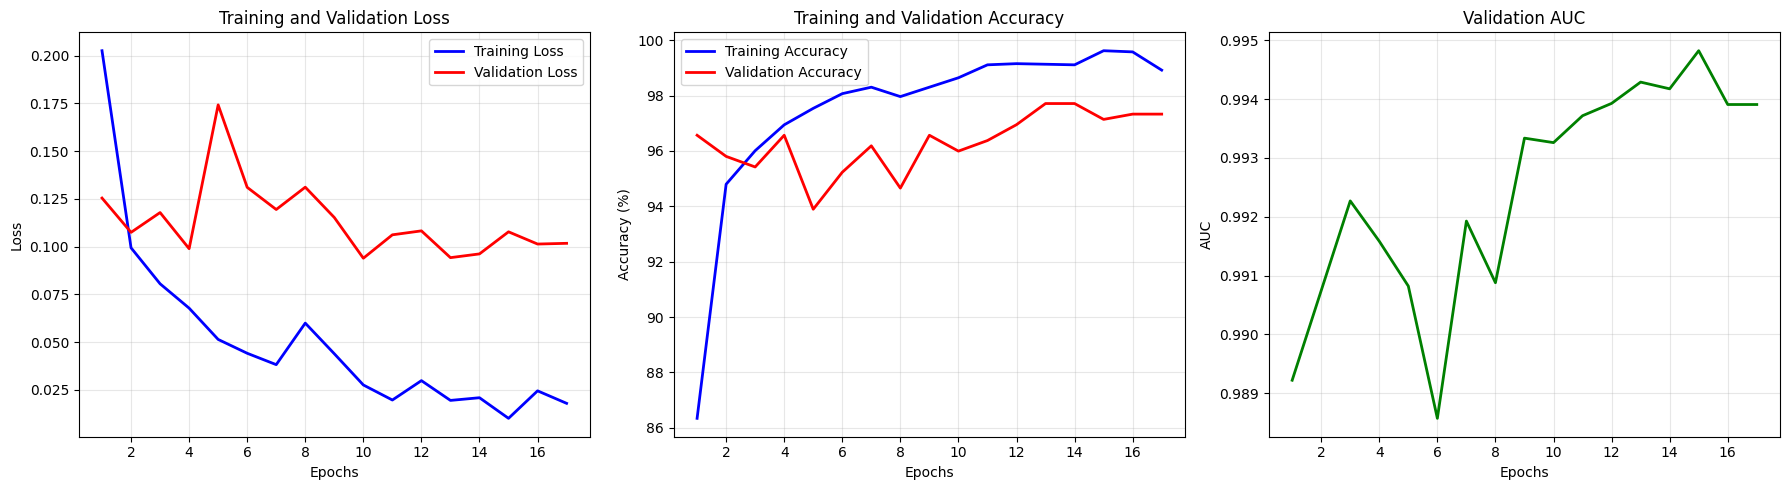

In [16]:
# Plot Training History
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # AUC plot
    axes[2].plot(epochs, history['val_auc'], 'g-', linewidth=2)
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('AUC')
    axes[2].set_title('Validation AUC')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)


TEST SET EVALUATION
Test Loss: 0.7055
Test Accuracy: 83.17%

Detailed Metrics:
  Sensitivity/Recall: 96.41%
  Specificity: 61.11%
  Precision: 80.51%
  F1-Score: 87.75%
  AUC-ROC: 0.9341


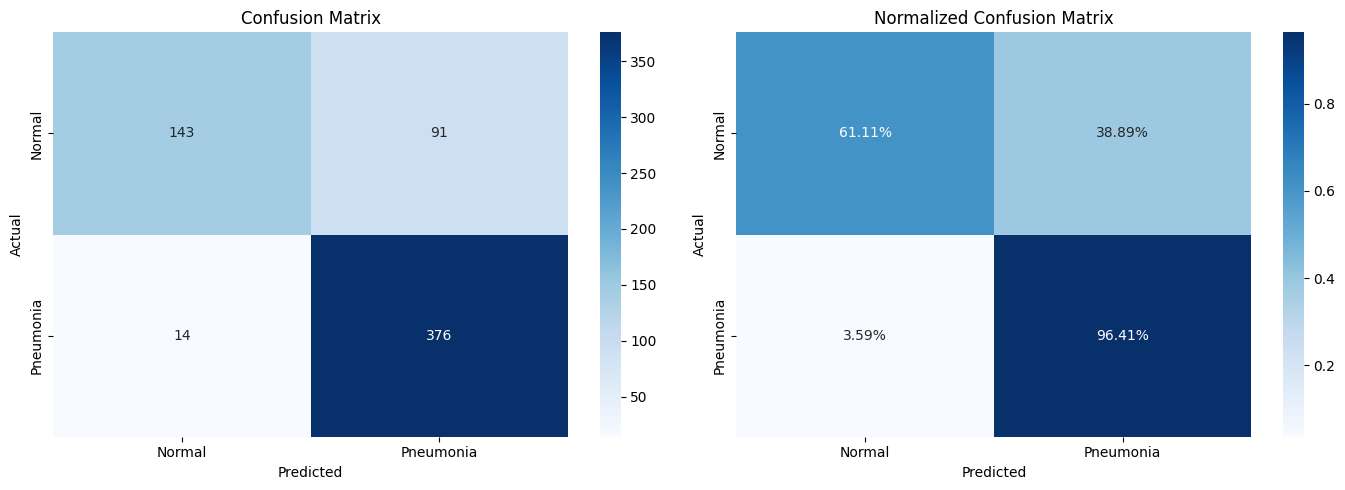

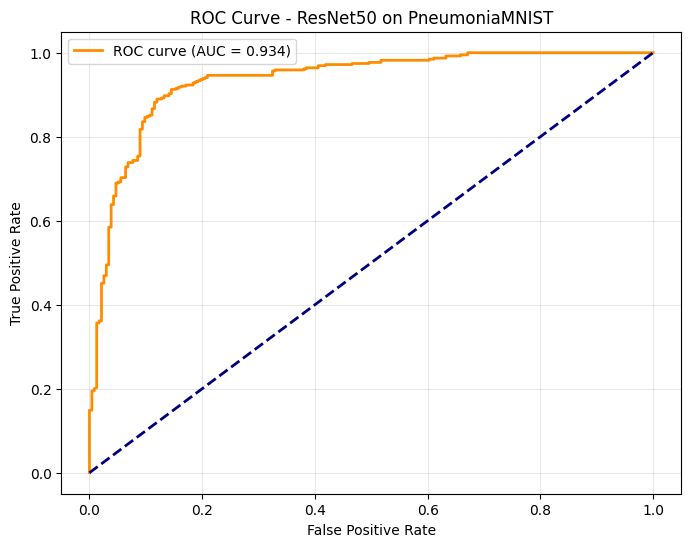


Classification Report:
              precision    recall  f1-score   support

      Normal       0.91      0.61      0.73       234
   Pneumonia       0.81      0.96      0.88       390

    accuracy                           0.83       624
   macro avg       0.86      0.79      0.80       624
weighted avg       0.84      0.83      0.82       624



In [ ]:
def evaluate_on_test(model, val_loader):
    criterion = nn.CrossEntropyLoss()

    print("\n" + "="*60)
    print("TEST SET EVALUATION")
    print("="*60)

    # Get predictions
    test_loss, test_acc, all_preds, all_labels, all_probs = validate(model, test_loader, criterion)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.2f}%")

    # Calculate metrics
    tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
    auc = roc_auc_score(all_labels, all_probs)

    print(f"\nDetailed Metrics:")
    print(f"  Sensitivity/Recall: {sensitivity:.2%}")
    print(f"  Specificity: {specificity:.2%}")
    print(f"  Precision: {precision:.2%}")
    print(f"  F1-Score: {f1:.2%}")
    print(f"  AUC-ROC: {auc:.4f}")

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    class_names = ['Normal', 'Pneumonia']

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title('Normalized Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - ResNet50 on PneumoniaMNIST')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return test_acc, auc

# Evaluate
test_accuracy, test_auc = evaluate_on_test(model, test_loader)